# Random Forest Model Performance

This notebook reviews the latest random forest outputs produced by `model_training.ipynb` under the spatial workflow. Final performance is the fixed NUTS3 test-set performance; training-region spatial CV remains a tuning diagnostic.


In [1]:
from __future__ import annotations

import json
import sys
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
try:
    from IPython.display import display
except Exception:
    display = print


In [2]:
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pipeline" / "config").exists()
)
sys.path.append(str(REPO_ROOT))
from pipeline.utils.paths import load_paths, path_value

rf_utils = import_module("pipeline.3_epvi_prediction.utils")
latest_file = rf_utils.latest_file
PATHS = load_paths()
MODEL_OUT_DIR = path_value(PATHS, "external_data_root") / "outputs" / "epvi_prediction" / "random_forest"

metrics_path = latest_file(MODEL_OUT_DIR, "rf_epvi_metrics_*.csv")
predictions_path = latest_file(MODEL_OUT_DIR, "rf_epvi_predictions_residuals_*.csv")
importances_path = latest_file(MODEL_OUT_DIR, "rf_epvi_feature_importances_*.csv")
params_path = latest_file(MODEL_OUT_DIR, "rf_epvi_best_params_*.json")
folds_path = latest_file(MODEL_OUT_DIR, "rf_epvi_spatial_cv_folds_*.csv")
permutation_path = latest_file(MODEL_OUT_DIR, "rf_epvi_permutation_importances_*.csv")
required = {"metrics": metrics_path, "predictions": predictions_path, "importances": importances_path, "params": params_path, "spatial folds": folds_path}
missing = [name for name, path in required.items() if path is None]
if missing:
    raise FileNotFoundError(f"Missing model outputs in {MODEL_OUT_DIR}: {missing}. Run the spatial training notebook first.")

print("model output folder:", MODEL_OUT_DIR)
for name, path in required.items():
    print(f"{name}:", path)
if permutation_path is not None:
    print("permutation importances:", permutation_path)


model output folder: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest
metrics: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_metrics_20260522_001417.csv
predictions: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_predictions_residuals_20260522_001417.csv
importances: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_feature_importances_20260522_001417.csv
params: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_best_params_20260522_001417.json
spatial folds: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_spatial_cv_folds_2

In [3]:
metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path)
importances = pd.read_csv(importances_path)
folds = pd.read_csv(folds_path)
with open(params_path, "r", encoding="utf-8") as f:
    best_params = json.load(f)
permutation_importances = pd.read_csv(permutation_path) if permutation_path is not None else pd.DataFrame()

target_order = metrics.sort_values("fixed_test_r2", ascending=False)["target"].tolist()
for df in [metrics, predictions, importances]:
    df["target"] = pd.Categorical(df["target"], categories=target_order, ordered=True)
print("targets:", target_order)
display(folds.sort_values(["target", "fold"]))


targets: ['AIAM', 'EPVI cooling', 'EPVI heating', 'EPG heating', 'EPG cooling']


,target,fold,n_rows,n_nuts3,validation_nuts3
10,AIAM,0,514,4,"PT11A, PT150, PT170, PT200"
11,AIAM,1,570,6,"PT11B, PT11C, PT16H, PT16I, PT187, PT300"
12,AIAM,2,514,4,"PT11D, PT16D, PT16F, PT16G"
13,AIAM,3,544,5,"PT111, PT119, PT181, PT185, PT186"
14,AIAM,4,516,4,"PT112, PT11E, PT16B, PT184"
5,EPG cooling,0,514,4,"PT11A, PT150, PT170, PT200"
6,EPG cooling,1,570,6,"PT11B, PT11C, PT16H, PT16I, PT187, PT300"
7,EPG cooling,2,514,4,"PT11D, PT16D, PT16F, PT16G"
8,EPG cooling,3,544,5,"PT111, PT119, PT181, PT185, PT186"
9,EPG cooling,4,516,4,"PT112, PT11E, PT16B, PT184"


## Fixed Spatial Test Metrics

These metrics come from models selected without the fixed test NUTS3 regions, fitted on all remaining training regions, and evaluated once on that fixed spatial test set.


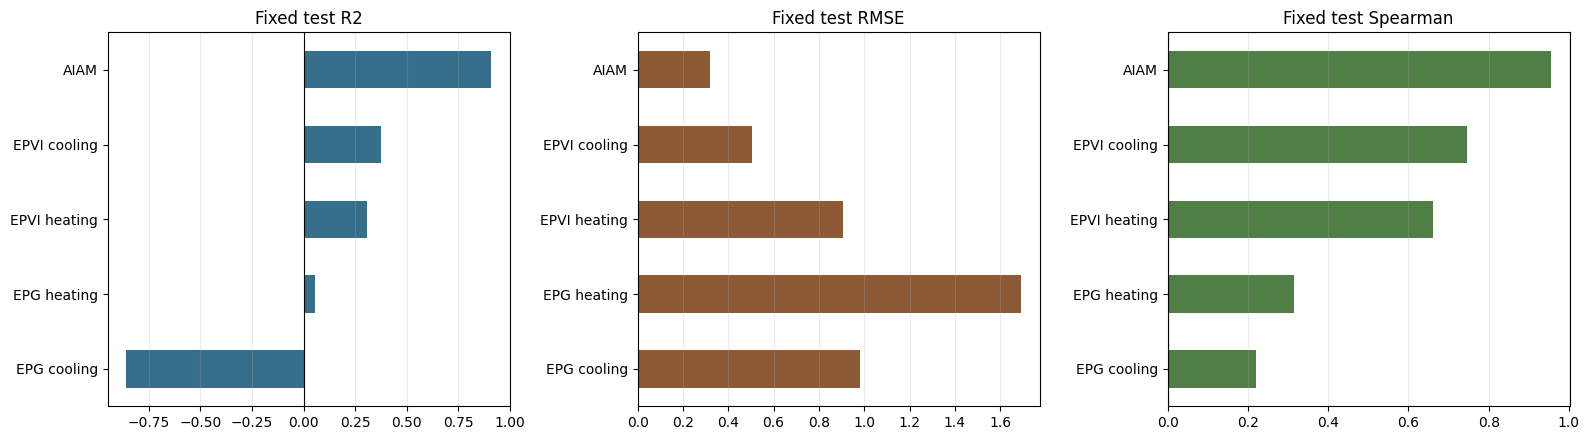

,target,n_train_rows,n_test_rows,n_predictors,fixed_test_r2,fixed_test_mae,fixed_test_rmse,fixed_test_spearman
0,AIAM,2658,434,46,0.911739,0.230861,0.317471,0.954270
1,EPVI cooling,2658,434,46,0.374057,0.435846,0.504822,0.746808
2,EPVI heating,2658,434,46,0.305987,0.579989,0.906150,0.661407
3,EPG heating,2658,434,46,0.053922,1.028053,1.689632,0.314364
4,EPG cooling,2658,434,46,-0.861937,0.895416,0.982949,0.221397


In [4]:
metric_cols = ["fixed_test_r2", "fixed_test_mae", "fixed_test_rmse", "fixed_test_spearman"]
plot_df = metrics.sort_values("fixed_test_r2", ascending=True)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_df.plot.barh(x="target", y="fixed_test_r2", ax=axes[0], legend=False, color="#356f8c")
axes[0].set_title("Fixed test R2")
axes[0].axvline(0, color="black", linewidth=0.8)
plot_df.plot.barh(x="target", y="fixed_test_rmse", ax=axes[1], legend=False, color="#8c5a35")
axes[1].set_title("Fixed test RMSE")
plot_df.plot.barh(x="target", y="fixed_test_spearman", ax=axes[2], legend=False, color="#4f7f45")
axes[2].set_title("Fixed test Spearman")
axes[2].axvline(0, color="black", linewidth=0.8)
for ax in axes:
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()
display(metrics[["target", "n_train_rows", "n_test_rows", "n_predictors", *metric_cols]].sort_values("fixed_test_r2", ascending=False))


## Training Spatial CV Diagnostic

These region-held-out metrics describe the tuning distribution on training regions. They are useful for comparison with the fixed test set but are not the final test result.


In [5]:
cv_cols = ["search_spatial_cv_r2_mean", "train_spatial_cv_r2", "train_spatial_cv_mae", "train_spatial_cv_rmse", "train_spatial_cv_spearman", "train_in_sample_r2"]
display(metrics[["target", *cv_cols]].sort_values("train_spatial_cv_r2", ascending=False))


,target,search_spatial_cv_r2_mean,train_spatial_cv_r2,train_spatial_cv_mae,train_spatial_cv_rmse,train_spatial_cv_spearman,train_in_sample_r2
0,AIAM,0.849739,0.855602,0.261011,0.381384,0.931376,0.968481
1,EPVI cooling,0.374986,0.490309,0.417002,0.561440,0.726741,0.890213
2,EPVI heating,0.397918,0.464012,0.553618,0.831624,0.716545,0.825923
3,EPG heating,0.039766,0.215703,1.013778,1.554598,0.388493,0.561905
4,EPG cooling,-0.033641,0.132475,0.724245,0.995531,0.363596,0.521536


## Fixed Test Predictions and Residuals


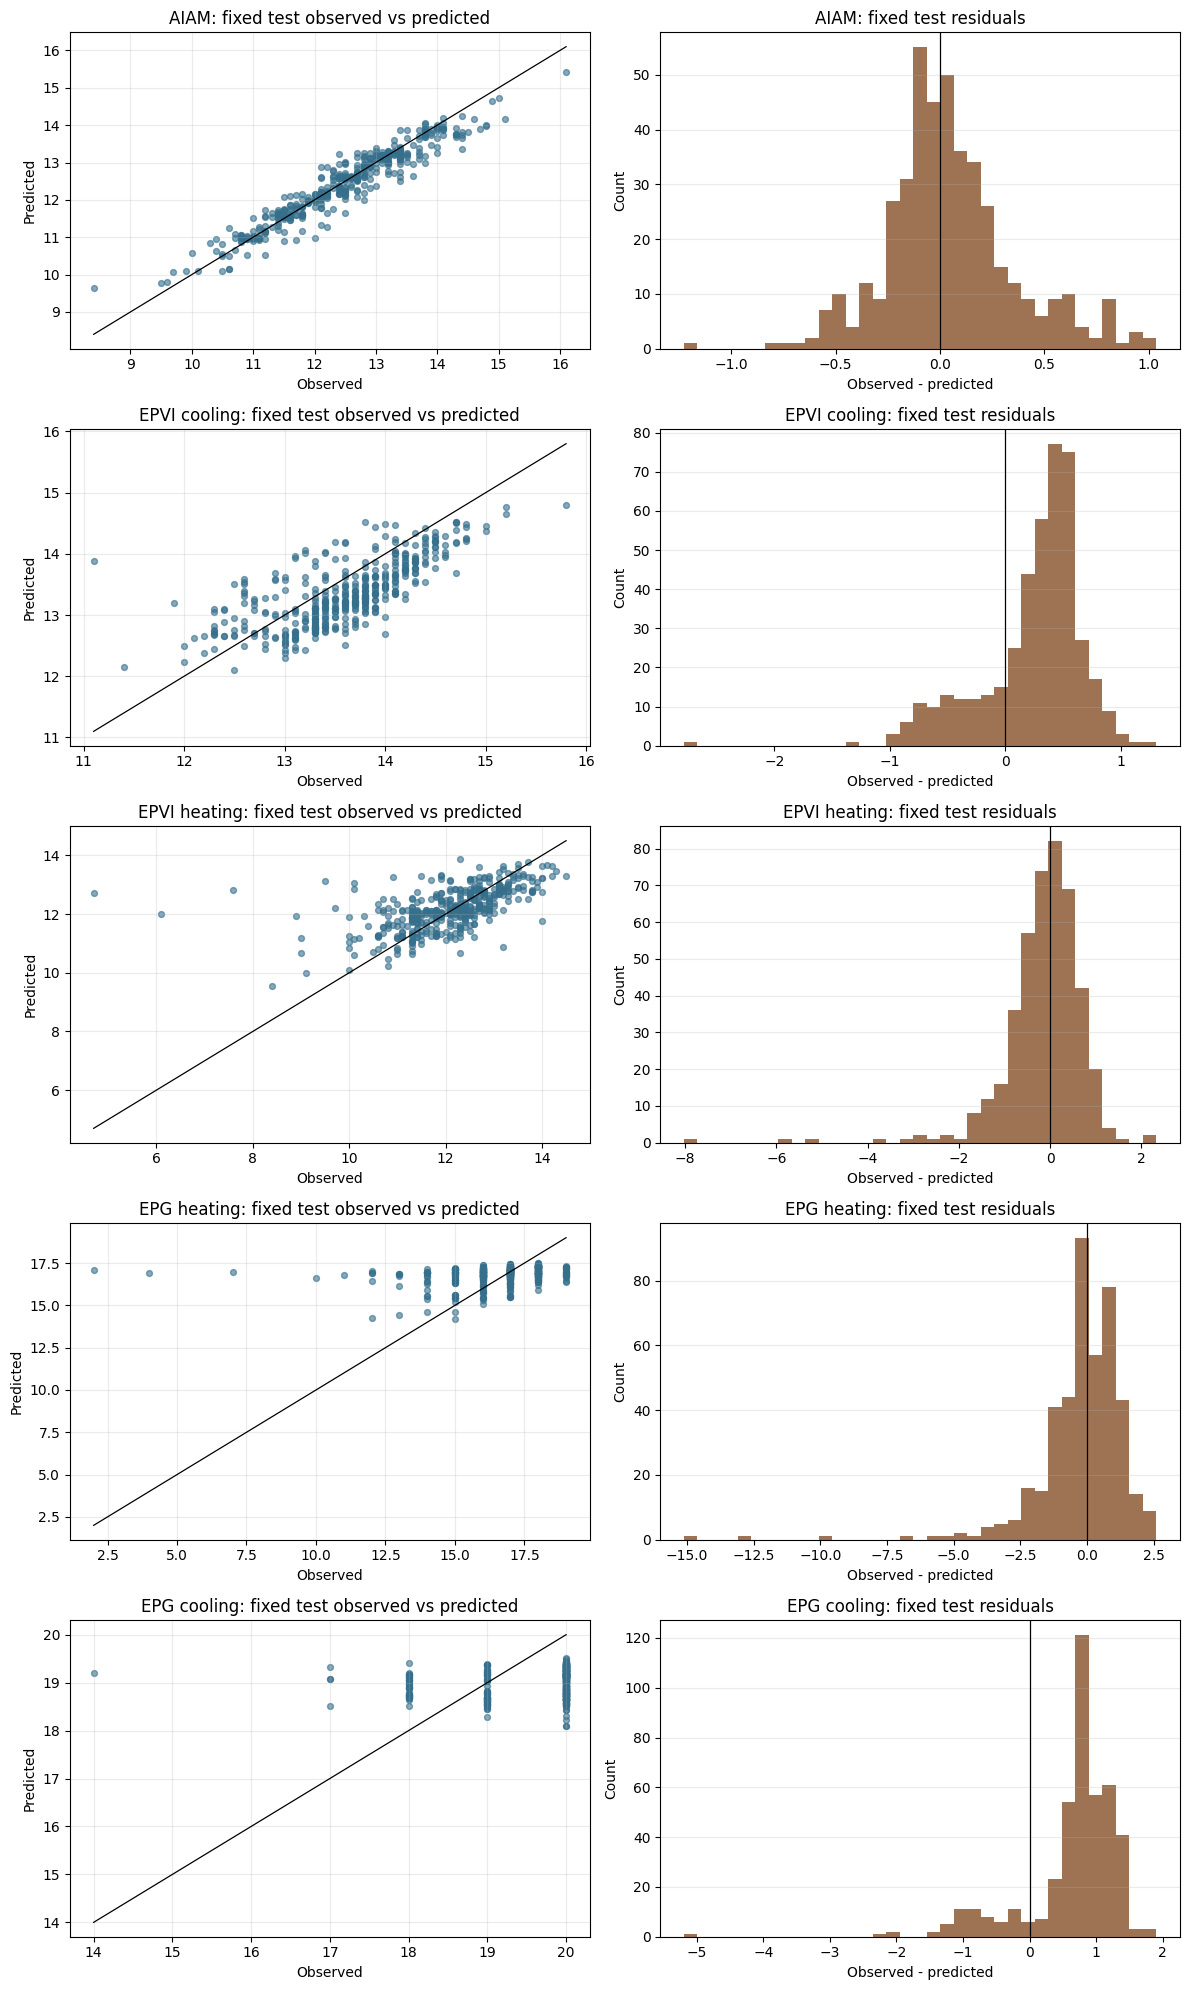

In [6]:
test_predictions = predictions[predictions["prediction_role"] == "fixed_test"].copy()
n_targets = len(target_order)
fig, axes = plt.subplots(n_targets, 2, figsize=(12, 4 * n_targets))
if n_targets == 1:
    axes = np.array([axes])
for row, target in enumerate(target_order):
    df_t = test_predictions[test_predictions["target"] == target].copy()
    ax = axes[row, 0]
    ax.scatter(df_t["observed"], df_t["predicted"], s=18, alpha=0.6, color="#356f8c")
    lo = min(df_t["observed"].min(), df_t["predicted"].min())
    hi = max(df_t["observed"].max(), df_t["predicted"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.9)
    ax.set_title(f"{target}: fixed test observed vs predicted")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
    ax = axes[row, 1]
    ax.hist(df_t["residual"].dropna(), bins=35, color="#8c5a35", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_title(f"{target}: fixed test residuals")
    ax.set_xlabel("Observed - predicted")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [7]:
largest_residuals = []
for target in target_order:
    df_t = test_predictions[test_predictions["target"] == target].copy()
    df_t["abs_residual"] = df_t["residual"].abs()
    largest_residuals.append(df_t.sort_values("abs_residual", ascending=False)[["target", "ID_norm", "NUTS3", "name", "observed", "predicted", "residual", "abs_residual"]].head(15))
display(pd.concat(largest_residuals, ignore_index=True))


,target,ID_norm,NUTS3,name,observed,predicted,residual,abs_residual
0,AIAM,061207,PT16E,Pessegueiro,8.4,9.627607,-1.227607,1.227607
1,AIAM,091109,PT16J,Baraçal,14.4,13.362518,1.037482,1.037482
2,AIAM,091201,PT16J,Alvoco da Serra,12.0,10.985763,1.014237,1.014237
3,AIAM,091313,PT16J,Palhais,13.6,12.632780,0.967220,0.967220
4,AIAM,060312,PT16E,Cernache,15.1,14.155497,0.944503,0.944503
5,AIAM,090209,PT16J,Freineda,12.2,11.276109,0.923891,0.923891
6,AIAM,090310,PT16J,Mesquitela,13.4,12.508168,0.891832,0.891832
7,AIAM,091307,PT16J,Fiães,12.5,11.661298,0.838702,0.838702
8,AIAM,091103,PT16J,Aldeia da Ponte,12.4,13.220492,-0.820492,0.820492
9,AIAM,090322,PT16J,Casas do Soeiro,14.8,13.981078,0.818922,0.818922


## Feature Importances

Impurity importances come from the final model fitted on training regions. Optional permutation importances, when written, are evaluated by the training notebook on the fixed test set.


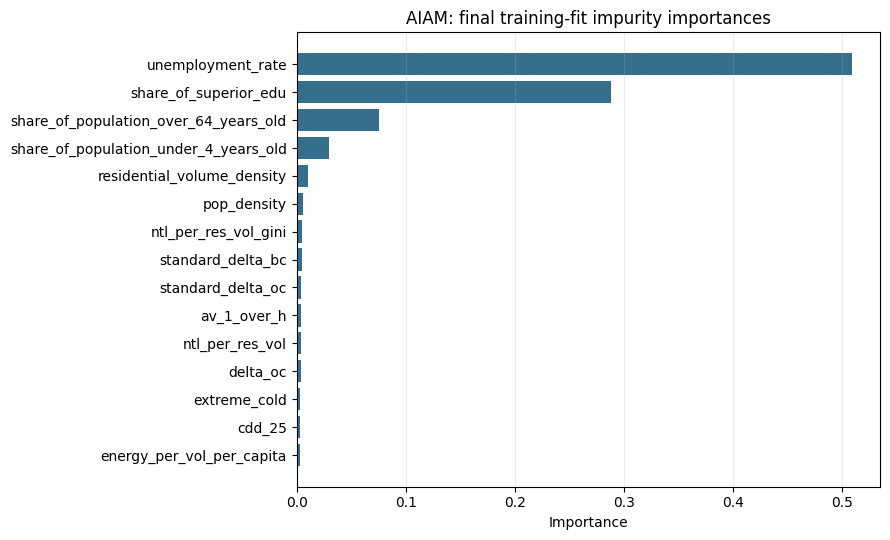

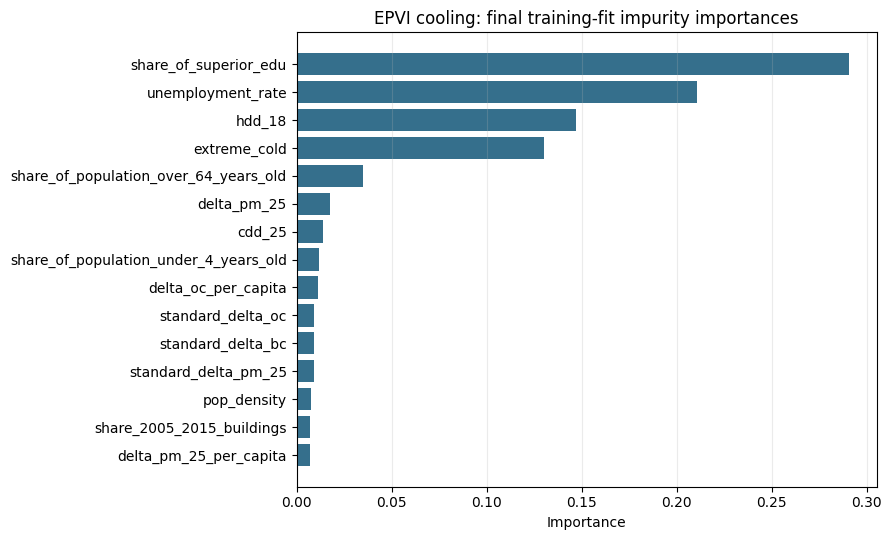

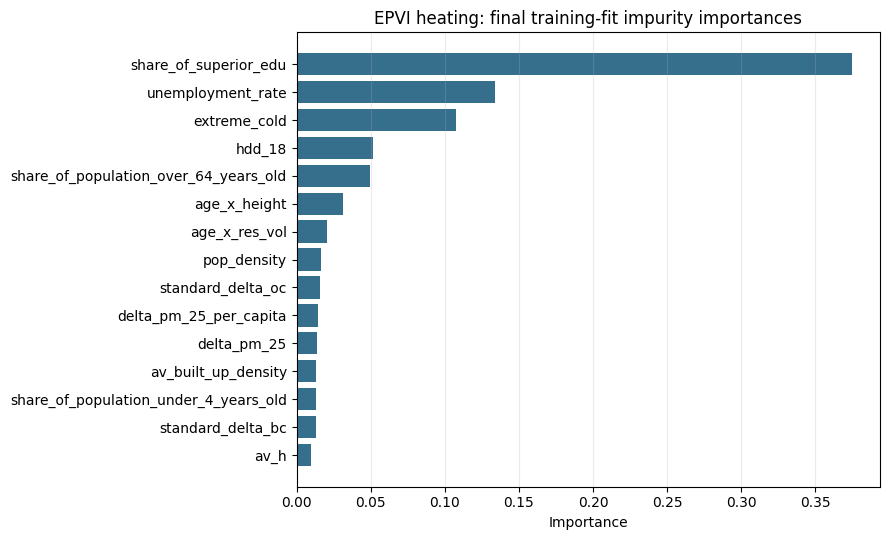

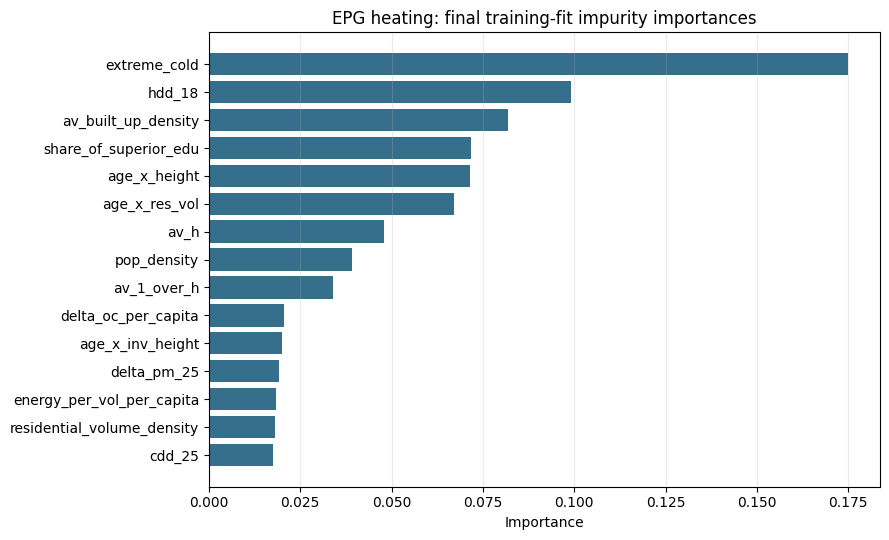

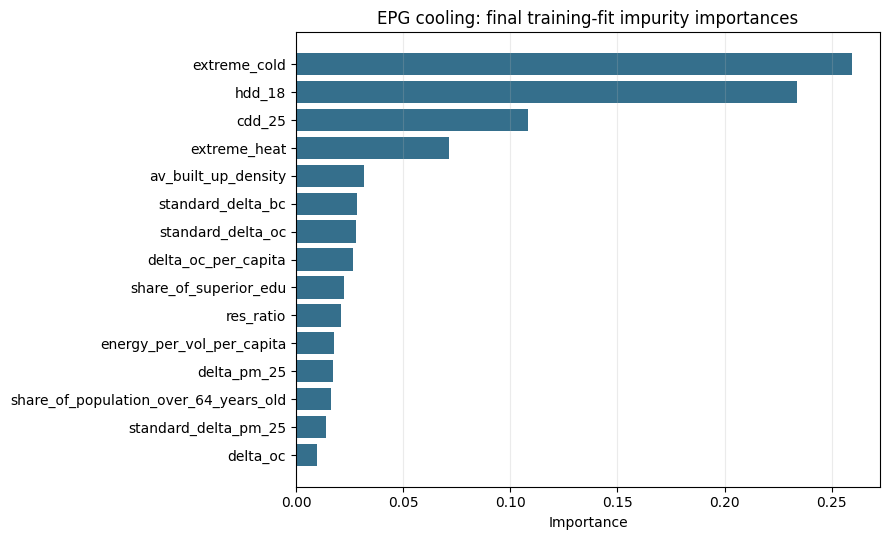

No permutation-importance output found. Enable RUN_PERMUTATION_IMPORTANCE in model_training.ipynb if needed.


In [8]:
TOP_N = 15
for target in target_order:
    df_t = importances[importances["target"] == target].sort_values("impurity_importance", ascending=True).tail(TOP_N)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(df_t["feature"], df_t["impurity_importance"], color="#356f8c")
    ax.set_title(f"{target}: final training-fit impurity importances")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()
if permutation_importances.empty:
    print("No permutation-importance output found. Enable RUN_PERMUTATION_IMPORTANCE in model_training.ipynb if needed.")
else:
    display(permutation_importances.groupby("target").head(15))


## Tuned Hyperparameters


In [9]:
params_df = pd.DataFrame(best_params).T
params_df.index.name = "target"
display(params_df)


,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
target,,,,,
EPG heating,600.0,30.0,12.0,0.20,6.0
EPG cooling,600.0,30.0,8.0,0.20,4.0
AIAM,800.0,10.0,2.0,0.75,24.0
EPVI heating,300.0,10.0,1.0,0.75,8.0
EPVI cooling,400.0,20.0,2.0,1.00,24.0
